In [1]:
import pyEDM
import pandas as pd
import numpy as np
import random
from collections import Counter

p22 = pd.read_csv('../data/processed_22.csv')
p23 = pd.read_csv('../data/processed_23.csv')
p24 = pd.read_csv('../data/processed_24.csv')
p25 = pd.read_csv('../data/processed_25.csv')
combined = pd.concat([p22, p23, p24, p25], ignore_index=True)

In [2]:
# top 20 features from paper + target variable + one additional taxa as predictor
features = [
    "Lpoly_expected_ml", "Area", "Biovolume", "MajorAxisLength",
    "MinorAxisLength", "Perimeter", "Orientation", "Eccentricity",
    "Solidity", "texture_uniformity", "texture_smoothness",
    "texture_average_gray_level", "texture_entropy",
    "texture_average_contrast", "H90", "H180", "Hflip",
    "Extent", "EquivDiameter", "ConvexArea", "ConvexPerimeter",
    "Pmicans_expected_ml" # add another taxa as a predictor
]

# process images features for MVE
df = combined[["date"] + features].copy()
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
df = df.sort_values("date").set_index("date")
df = df.asfreq("D")

# fill missing values using ema
df_filled = df.copy()
for col in features:
    ema = df[col].ewm(span=30, adjust=False).mean()
    df_filled[col] = df[col].fillna(ema)

# normalize features
df_norm = df_filled.copy()
for col in features:
    mu = df_filled[col].mean()
    sigma = df_filled[col].std()
    df_norm[col] = (df_filled[col] - mu) / sigma

df_mv = df_norm.copy()
df_mv = df_mv.reset_index()
df_mv["t"] = np.arange(1, len(df_mv) + 1)
df_mv = df_mv[["t"] + features]

target = "Lpoly_expected_ml"
predictors = [col for col in features if col != target]

df_mv.head()

,t,Lpoly_expected_ml,Area,Biovolume,MajorAxisLength,MinorAxisLength,Perimeter,Orientation,Eccentricity,Solidity,...,texture_entropy,texture_average_contrast,H90,H180,Hflip,Extent,EquivDiameter,ConvexArea,ConvexPerimeter,Pmicans_expected_ml
0,1,0.285287,1.059338,0.967595,0.956625,1.139942,1.226418,0.842266,-1.228078,-0.191169,...,0.480870,-1.005885,-0.901014,0.861091,1.128490,0.102206,1.092577,1.111408,1.118301,-0.249353
1,2,0.065656,1.016480,0.917837,0.908034,1.109145,1.007938,0.563761,-1.247322,0.526462,...,0.640061,-0.878977,-1.001016,0.340277,0.680457,0.656972,1.062576,0.999125,1.020599,-0.263835
2,3,-0.128818,0.671753,0.512658,0.637894,0.852846,0.719154,0.645106,-1.070290,0.486697,...,0.996070,-0.759717,-0.976040,0.078281,0.314316,0.520649,0.807369,0.659696,0.771253,0.039442
3,4,-0.018094,0.379651,0.165389,0.433051,0.632838,0.501162,0.894757,-0.832234,0.370645,...,1.106370,-0.779254,-0.852571,0.097279,0.420381,0.192816,0.595165,0.375226,0.570793,0.721472
4,5,0.891676,0.756008,0.593485,0.724495,0.928235,0.917121,0.418304,-1.071257,0.091247,...,0.232139,-0.948879,-0.995896,0.312944,0.654387,0.256093,0.879835,0.773202,0.863842,0.284220


In [3]:
# process environmental data
env = pd.read_csv("../data/environment_all.csv")

# could be relevant but too many missing values for ema imputation to be effective
env = env.drop(columns=[
    'fluorescent_dissolved_organic_matter_eco',
    'sea_water_turbidity_eco',
    'waterlevel_predicted_m',
    'mass_concentration_of_oxygen_in_sea_water_seaphox',
    'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water_seaphox',
    'fractional_saturation_of_oxygen_in_sea_water_seaphox',
    'sea_water_ph_reported_on_total_scale_seaphox_external'
])

env["date"] = pd.to_datetime(env["date"].astype(str), format="%Y%m%d")
env = env.sort_values("date").set_index("date")
env = env.asfreq("D")

env_features = env.columns.tolist()
env_filled = env.copy()

# fill missing values using ema
for col in env_features:
    ema = env[col].ewm(span=30, adjust=False).mean()
    env_filled[col] = env[col].fillna(ema)

# normalize features
df_norm = env_filled.copy()
for col in env_features:
    mu = env_filled[col].mean()
    sigma = env_filled[col].std()
    df_norm[col] = (env_filled[col] - mu) / sigma

df_env = df_norm.copy()
df_env = df_env.reset_index()
df_env["t"] = np.arange(1, len(df_env) + 1)
df_env = df_env[["t"] + env_features]

# merge mv features with env features for combined model
df_all = pd.merge(df_mv, df_env, on="t", how="inner")

# merge with target variable for MVE
df_env = df_env.merge(df_mv[["t", target]], on="t", how="inner")

https://sugiharalab.github.io/EDM_Documentation/parameters/

In [4]:
def one_simplex(df, target, features, E=4, Tp=1):
    # Randomly select 3 features (+ the target) for the simplex projection
    chosen_features = random.sample(features, 3)
    columns = [target] + chosen_features
    columns_str = " ".join(columns) # has to be 'space separated' idk ????

    N = len(df)
    res = pyEDM.Simplex(
        dataFrame=df,
        columns=columns_str,
        target=target,
        E=E,
        tau=1,
        Tp=Tp,
        lib=f"1 {N}",
        pred=f"1 {N}"
    )

    obs = res["Observations"].to_numpy()
    pred = res["Predictions"].to_numpy()

    mask = np.isfinite(obs) & np.isfinite(pred)
    obs = obs[mask]
    pred = pred[mask]

    if len(obs) < 10 or np.std(obs) == 0 or np.std(pred) == 0:
        return np.nan, chosen_features

    rho = np.corrcoef(obs, pred)[0, 1]
    rmse = np.sqrt(np.mean((obs - pred) ** 2))
    mae = np.mean(np.abs(obs - pred))
    return rho, rmse, mae, chosen_features

def multiview_big(df, target, features, Tp, n_trials=500):
    results = []

    for i in range(n_trials):
        rho, rmse, mae, chosen = one_simplex(df, target, features, E=4, Tp=Tp)

        results.append({
            "rho": rho,
            "rmse": rmse,
            "mae": mae,
            "features": chosen
        })

    return pd.DataFrame(results)

def multiview_yes(df_mv, target, predictors):
    # wrapper main function
    x = df_mv[target].to_numpy()

    summary_rows = []
    feature_importance_by_tp = {}
    
    for Tp in range(1, 32):
        mv = multiview_big(df_mv, target, predictors, Tp, n_trials=500)

        acf = abs(pd.Series(x).autocorr(lag=Tp))
        mv["rho_eff"] = mv["rho"] - acf

        # summary stats
        summary_rows.append({
            "Tp": Tp,
            "rho_mean": mv["rho"].mean(),
            "acf": acf,
            "rho_eff_mean": mv["rho_eff"].mean(),
            "rmse_mean": mv["rmse"].mean(),
            "mae_mean": mv["mae"].mean(),
            "n_models": len(mv)
        })

        # feature importance (top 5%)
        top = mv.nlargest(int(0.05 * len(mv)), "rho_eff")

        counts = Counter()
        for feats in top["features"]:
            for f in feats:
                counts[f] += 1

        importance = pd.Series(counts) / len(top)
        feature_importance_by_tp[Tp] = importance.sort_values(ascending=False)
    
    return summary_rows, feature_importance_by_tp

##### Image Features

In [5]:
summary_rows_img = []
feature_importance_by_tp_img = {}

summary_rows_img, feature_importance_by_tp_img = multiview_yes(df_mv, target, predictors)
summary_df_img = pd.DataFrame(summary_rows_img)
print(summary_df_img)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.940260  0.750836      0.189425   0.440011  0.083584       500
1    2  0.949230  0.507478      0.441753   0.402816  0.078769       500
2    3  0.948140  0.363468      0.584672   0.377936  0.080223       500
3    4  0.594006  0.323560      0.270446   0.810665  0.181702       500
4    5  0.407913  0.282526      0.125387   0.945027  0.216652       500
5    6  0.363030  0.199548      0.163482   0.965803  0.225700       500
6    7  0.302328  0.162179      0.140149   0.982714  0.237418       500
7    8  0.239255  0.160931      0.078324   0.999957  0.240623       500
8    9  0.250582  0.149251      0.101331   0.997017  0.239486       500
9   10  0.252612  0.174992      0.077620   0.996410  0.243729       500
10  11  0.232600  0.157892      0.074708   1.004105  0.247695       500
11  12  0.201220  0.141327      0.059893   1.024774  0.265396       500
12  13  0.169185  0.147118      0.022068   1.045047  0.278924   

In [6]:
importance_all_img = pd.concat(
    feature_importance_by_tp_img,
    names=["Tp", "Feature"]
).reset_index()

importance_all_img.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_img)

##### Environmental Features

In [7]:
summary_rows_env = []
feature_importance_by_tp_env = {}

summary_rows_env, feature_importance_by_tp_env = multiview_yes(df_env, target, env_features)
summary_df_env = pd.DataFrame(summary_rows_env)
print(summary_df_env)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.930821  0.750836      0.179985   0.457849  0.119175       500
1    2  0.942071  0.507478      0.434593   0.421940  0.114055       500
2    3  0.938499  0.363468      0.575031   0.404236  0.117016       500
3    4  0.591987  0.323560      0.268427   0.810831  0.203952       500
4    5  0.414958  0.282526      0.132433   0.931421  0.232511       500
5    6  0.390532  0.199548      0.190984   0.942334  0.239159       500
6    7  0.351050  0.162179      0.188871   0.957654  0.249588       500
7    8  0.270056  0.160931      0.109125   0.995419  0.262141       500
8    9  0.280842  0.149251      0.131590   0.982373  0.259762       500
9   10  0.288814  0.174992      0.113822   0.986517  0.267813       500
10  11  0.298198  0.157892      0.140306   0.990875  0.277492       500
11  12  0.336826  0.141327      0.195499   0.989230  0.289139       500
12  13  0.367808  0.147118      0.220691   0.974932  0.292583   

In [8]:
importance_all_env = pd.concat(
    feature_importance_by_tp_env,
    names=["Tp", "Feature"]
).reset_index()

importance_all_env.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_env)

##### Combined

In [9]:
summary_rows_com = []
feature_importance_by_tp_com = {}

summary_rows_com, feature_importance_by_tp_com = multiview_yes(df_all, target, predictors+env_features)
summary_df_com = pd.DataFrame(summary_rows_com)
print(summary_df_com)

    Tp  rho_mean       acf  rho_eff_mean  rmse_mean  mae_mean  n_models
0    1  0.937129  0.750836      0.186294   0.445693  0.094405       500
1    2  0.946648  0.507478      0.439170   0.409962  0.089785       500
2    3  0.944562  0.363468      0.581094   0.387048  0.091410       500
3    4  0.589698  0.323560      0.266138   0.813675  0.188823       500
4    5  0.405962  0.282526      0.123436   0.944292  0.221347       500
5    6  0.372985  0.199548      0.173437   0.958047  0.228079       500
6    7  0.329115  0.162179      0.166936   0.969898  0.237096       500
7    8  0.263816  0.160931      0.102886   0.991135  0.241059       500
8    9  0.277071  0.149251      0.127819   0.982904  0.239004       500
9   10  0.271426  0.174992      0.096434   0.987303  0.243694       500
10  11  0.260873  0.157892      0.102981   0.994785  0.250352       500
11  12  0.263437  0.141327      0.122110   1.006937  0.267483       500
12  13  0.257176  0.147118      0.110059   1.012907  0.276610   

In [10]:
importance_all_com = pd.concat(
    feature_importance_by_tp_com,
    names=["Tp", "Feature"]
).reset_index()

importance_all_com.columns = ["Tp", "Feature", "Proportion"]
# print(importance_all_com)

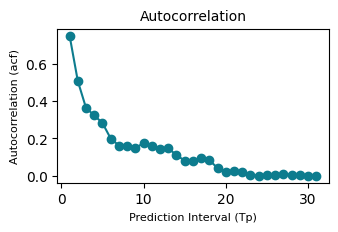

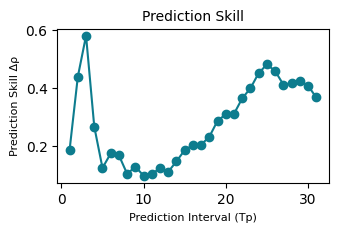

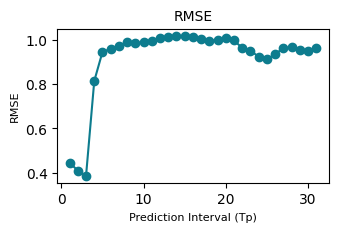

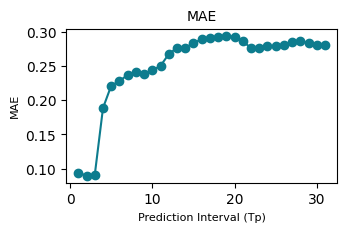

In [11]:
import matplotlib.pyplot as plt

# acf over tp
plt.figure(figsize=(3.5, 2))
plt.plot(summary_df_com["Tp"], summary_df_com["acf"], marker="o", color="#0d7c8e")
plt.xlabel("Prediction Interval (Tp)", fontsize=8)
plt.ylabel("Autocorrelation (acf)", fontsize=8)
plt.title("Autocorrelation", fontsize=10)
plt.show()

plt.figure(figsize=(3.5, 2))
plt.plot(summary_df_com["Tp"], summary_df_com["rho_eff_mean"], marker="o", color="#0d7c8e")
plt.xlabel("Prediction Interval (Tp)", fontsize=8)
plt.ylabel("Prediction Skill Δρ", fontsize=8)
plt.title("Prediction Skill", fontsize=10)
plt.show()

plt.figure(figsize=(3.5, 2))
plt.plot(summary_df_com["Tp"], summary_df_com["rmse_mean"], marker="o", color="#0d7c8e")
plt.xlabel("Prediction Interval (Tp)", fontsize=8)
plt.ylabel("RMSE", fontsize=8)
plt.title("RMSE", fontsize=10)
plt.show()

plt.figure(figsize=(3.5, 2))
plt.plot(summary_df_com["Tp"], summary_df_com["mae_mean"], marker="o", color="#0d7c8e")
plt.xlabel("Prediction Interval (Tp)", fontsize=8)
plt.ylabel("MAE", fontsize=8)
plt.title("MAE", fontsize=10)
plt.show()

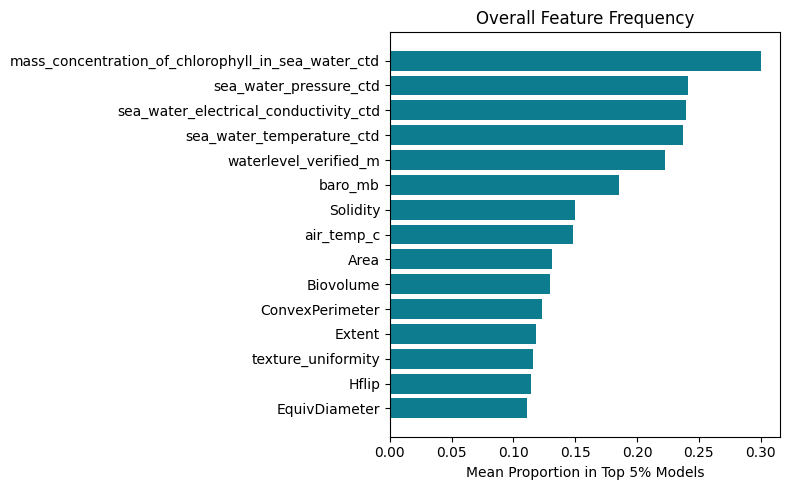

In [12]:
mean_importance = (
    importance_all_com
    .groupby("Feature")["Proportion"]
    .mean()
    .sort_values(ascending=False)
)

top_plot = mean_importance.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top_plot.index, top_plot.values, color="#0d7c8e")
plt.xlabel("Mean Proportion in Top 5% Models")
plt.title("Overall Feature Frequency")
plt.tight_layout()
plt.show()

^^ using combined